In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
Figs_path = '/net/mraid20/export/genie/LabData/Analyses/DeepVoiceFolder/Oct25_voice_full_length/figures/'
from LabData.DataLoaders.BodyMeasuresLoader import BodyMeasuresLoader

In [219]:
bm_loader = BodyMeasuresLoader()
bm_data = bm_loader.get_data().df

In [232]:
bm_data.reset_index(inplace=True)

In [233]:
# get all rows with 10K prefix in RegistrationCode
count_10k = bm_data[bm_data['RegistrationCode'].str.startswith('10K_')]

In [235]:
count_10k.RegistrationCode.nunique()

13504

In [3]:
subject_df = pd.read_csv('/net/mraid20/export/genie/LabData/Analyses/DeepVoiceFolder/Oct25_voice_full_length/subject_details_df_Oct25.csv')         

In [4]:
demographics_df = (
    subject_df[["subject_number", "age", "gender"]]     # keep only the three columns
      .drop_duplicates()                        # remove exact duplicates
      .reset_index(drop=True)                   # clean, consecutive index
)

In [5]:

demographics_df = demographics_df.assign(gender_label=lambda d: d["gender"]
                                   .map({0: "female", 1: "male"}))


In [6]:
# limit to ages 40-70
demographics_df = demographics_df[
    (demographics_df["age"] >= 40) & (demographics_df["age"] <= 70)
]

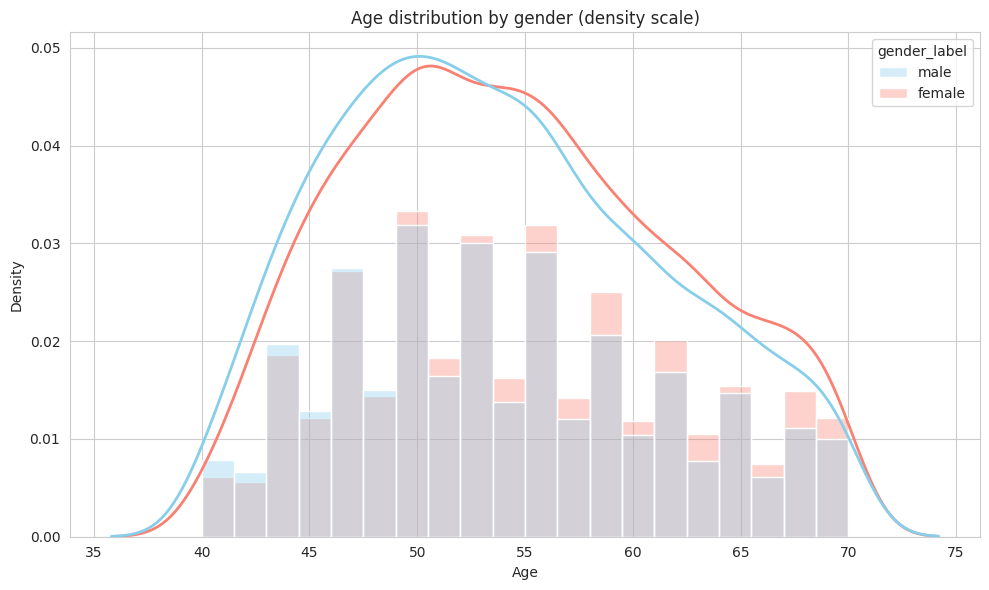

In [7]:
sns.set_style("whitegrid")
palette = {"female": "salmon", "male": "skyblue"}

fig, ax = plt.subplots(figsize=(10, 6))

# histogram in density units
sns.histplot(
    data=demographics_df,
    x="age",
    hue="gender_label",
    palette=palette,
    multiple="layer",
    stat="density",          # ← key line
    bins=20,
    alpha=0.35,
    edgecolor=None,
    ax=ax,
)

# KDE (already in density units)
for gender, color in palette.items():
    sns.kdeplot(
        data=demographics_df.query("gender_label == @gender"),
        x="age",
        ax=ax,
        color=color,
        linewidth=2,
        fill=False,
        common_norm=False,    # keeps each gender separate
    )

ax.set_xlabel("Age")
ax.set_ylabel("Density")
ax.set_title("Age distribution by gender (density scale)")
plt.tight_layout()
plt.savefig(Figs_path + 'age_distribution_density_plot.png')
plt.show()


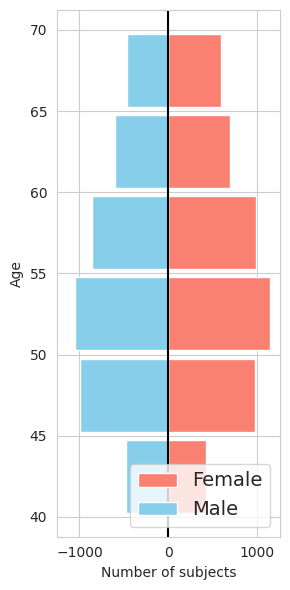

In [238]:
bins = np.arange(40, 75, 5)              # 5‑year bins 40–70
bin_centres = bins[:-1] + 2.5            # bar positions

male   = demographics_df[demographics_df["gender"] == 1]["age"]
female = demographics_df[demographics_df["gender"] == 0]["age"]

male_counts,   _ = np.histogram(male,   bins=bins)
female_counts, _ = np.histogram(female, bins=bins)

# ── plotting ──────────────────────────────────────────────────────────
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(3, 6))

# bars: female to the right, male to the left (negative width)
ax.barh(bin_centres,  female_counts, height=4.5, label="Female", color="salmon")
ax.barh(bin_centres, -male_counts,  height=4.5, label="Male",   color="skyblue")

# tidy up axes
max_count = max(female_counts.max(), male_counts.max())
ax.set_xlim(-max_count * 1.1, max_count * 1.1)
ax.set_xlabel("Number of subjects")
ax.set_ylabel("Age")
# ax.set_title("Age distribution by gender")
ax.legend(loc="lower right", fontsize=14)
ax.axvline(0, color="black")             # centre line
plt.tight_layout()
plt.savefig(Figs_path + 'age_distribution_population_plot.png', dpi=600)
plt.savefig(Figs_path + 'age_distribution_population_plot.pdf')
plt.show()

## Box-plots curves

In [2]:
gender = 'female'
DeepFolderPath = "/net/mraid20/export/genie/LabData/Analyses/DeepVoiceFolder/Oct25_voice_full_length/"
age_predictions_path = DeepFolderPath + f"Ridge_stuff/multi_seed_Age_{gender}/predictions_averaged.csv"
Figs_path = DeepFolderPath + "figures/"

In [3]:
predictions_table = pd.read_csv(age_predictions_path, index_col=0)
predictions_table = predictions_table.rename(columns={'mean_predictions': 'predictions'})
predictions_table['fold'] = 0
risk_factors_merged = pd.read_csv(os.path.join(DeepFolderPath, 'merged_risk_factors_subject_details.csv'), index_col=0)

In [4]:
risk_factors_merged.index

Index(['9635947353_20250925', '1016331244_20250714', '4821975374_20250826',
       '8581452551_20200225', '1480390506_20250925', '5349318625_20240929',
       '4223410928_20240211', '3282121140_20240620', '4905163105_20240128',
       '9384633644_20241209',
       ...
       '6531480647_20200220', '8756917375_20240508', '1729229847_20231206',
       '2257248963_20231221', '1042122294_20241106', '9364050655_20250728',
       '8238074646_20240130', '4491698222_20231218', '7518420954_20200629',
       '2911036416_20230827'],
      dtype='object', name='filename', length=10104)

In [5]:
predictions_table_merged = predictions_table.join(risk_factors_merged.drop('gender', axis=1))

In [6]:
from scipy.stats import zscore

def add_age_percentile_by_bin(predictions_table, bin_width=2, min_age=40, max_age=72):
    """
    Add a column 'age_percentile' to predictions_table containing the z-score
    of predicted age within each age bin (based on true_values).
    
    Parameters
    ----------
    predictions_table : pd.DataFrame
        DataFrame with columns 'true_values', 'predictions', 'subject_number', 'visit_priority', 'visit_number'
    bin_width : int, default 2
        Width of each age bin in years
    min_age : int, default 40
        Minimum age for binning
    max_age : int, default 72
        Maximum age for binning
    
    Returns
    -------
    pd.DataFrame
        Copy of predictions_table with added 'age_percentile' column containing z-scores
    """
    # Copy and clean the data
    df = predictions_table.copy()
    df_clean = df.dropna(subset=['true_values', 'predictions',
                                 'subject_number', 'visit_number'])
    
    # Keep only the last visit for each subject
    df_filtered = df_clean.copy()
    
    # Create age bins
    df_filtered['age_bin'] = (np.floor(df_filtered['true_values'] / bin_width) * bin_width).astype(int)
    
    # Calculate z-score within each bin
    def calc_zscore(group):
        """Calculate z-score for each prediction within the group"""
        if len(group) > 1:
            return zscore(group['predictions'])
        else:
            return pd.Series([0.0], index=group.index)
    
    # Apply z-score calculation per bin
    df_filtered['age_percentile'] = df_filtered.groupby('age_bin', group_keys=False).apply(calc_zscore)
    
    # Merge back to original dataframe
    result = predictions_table.copy()
    result['age_percentile'] = np.nan
    result.loc[df_filtered.index, 'age_percentile'] = df_filtered['age_percentile']
    
    return result

In [7]:
def analyze_age_predictions(predictions_table, 
                            min_age=40, 
                            max_age=72,
                            percentile=0.1,
                            bin_width=2):
    """
    Analyze age predictions data:
    1. Clean data by removing missing values and filtering to last instance per subject
    2. Group participants into age bins of configurable width based on true age values
    3. Identify indices for top X% and bottom X% of predicted ages within each bin
    4. Aggregate all top and bottom percentile groups across all bins
    
    Args:
        predictions_table (DataFrame): DataFrame with columns 
            'true_values', 'predictions', 'fold', 'subject_number', 'visit_priority', 'visit_number'
        min_age (int): Minimum age for binning (default: 40)
        max_age (int): Maximum age for binning (default: 70)
        percentile (float): Fraction (0-1) defining top and bottom percentile (default: 0.1)
        bin_width (int): Width of each age bin in years (default: 2)
        
    Returns:
        tuple: (age_bins_dict, top_percent_by_bin, bottom_percent_by_bin, 
                aggregated_top_percent, aggregated_bottom_percent)
    """
    # Copy and clean the data
    df = predictions_table.copy()

    df_clean = df.dropna(subset=['true_values', 'predictions', 
                                 'subject_number', 'visit_number'])
    print(f"Loaded {len(df_clean)} valid data points from {len(df)} total rows")
    
    # Keep only the last visit for each subject (visit_priority lowest = latest)
    # idx = df_clean.groupby('subject_number')['visit_priority'].idxmin()
    # df_filtered = df_clean.loc[idx]
    df_filtered = df_clean.copy()
    # df_filtered.index = df_filtered['subject_number'].astype(str) + '_' + df_filtered['visit_number'].astype(str)
    
    print(f"After filtering to last instance per subject: {len(df_filtered)} data points from "
          f"{df_clean['subject_number'].nunique()} unique subjects")
    
    df = df_filtered
    
    # Initialize dictionaries
    age_bins_dict = {}
    top_percent_by_bin = {}
    bottom_percent_by_bin = {}
    aggregated_top_percent = []
    aggregated_bottom_percent = []
    
    # Create bins dynamically based on bin_width
    bin_labels = []
    for bin_start in range(min_age, max_age, bin_width):
        bin_end = bin_start + bin_width - 1
        bin_name = f"{bin_start}-{bin_end}"
        bin_labels.append(bin_name)
        age_bins_dict[bin_name] = []
        top_percent_by_bin[bin_name] = []
        bottom_percent_by_bin[bin_name] = []
    
    # Assign rows to bins
    for idx, row in df.iterrows():
        age = row['true_values']
        bin_start = int(np.floor(age / bin_width) * bin_width)
        bin_end = bin_start + bin_width - 1
        bin_name = f"{bin_start}-{bin_end}"
        if bin_name in age_bins_dict:
            age_bins_dict[bin_name].append(idx)
    
    # Compute top and bottom percentile per bin
    for bin_name in bin_labels:
        bin_indices = age_bins_dict[bin_name]
        if len(bin_indices) == 0:
            continue
        
        bin_df = df.loc[bin_indices]
        if len(bin_df) < 10:
            min_idx = bin_df['predictions'].idxmin()
            max_idx = bin_df['predictions'].idxmax()
            bottom_percent_by_bin[bin_name] = [min_idx]
            top_percent_by_bin[bin_name] = [max_idx]
        else:
            bottom_thr = bin_df['predictions'].quantile(percentile)
            top_thr = bin_df['predictions'].quantile(1 - percentile)
            bottom_ids = bin_df[bin_df['predictions'] <= bottom_thr].index.tolist()
            top_ids = bin_df[bin_df['predictions'] >= top_thr].index.tolist()
            bottom_percent_by_bin[bin_name] = bottom_ids
            top_percent_by_bin[bin_name] = top_ids
        
        aggregated_top_percent.extend(top_percent_by_bin[bin_name])
        aggregated_bottom_percent.extend(bottom_percent_by_bin[bin_name])
    
    # Summary
    print(f"Total participants after filtering: {len(df)}")
    print(f"Number of age bins: {len([b for b in age_bins_dict.keys() if age_bins_dict[b]])}")
    percent = percentile * 100
    print("\nDistribution across age bins:")
    for bin_name in bin_labels:
        total = len(age_bins_dict[bin_name])
        top_n = len(top_percent_by_bin[bin_name])
        bottom_n = len(bottom_percent_by_bin[bin_name])
        print(f"  {bin_name}: {total} participants, Top {percent}%: {top_n}, Bottom {percent}%: {bottom_n}")
    
    print(f"\nTotal in aggregated top {percent}%: {len(aggregated_top_percent)}")
    print(f"Total in aggregated bottom {percent}%: {len(aggregated_bottom_percent)}")
    
    return (age_bins_dict, top_percent_by_bin, bottom_percent_by_bin,
            aggregated_top_percent, aggregated_bottom_percent)


In [11]:
age_percent_results = analyze_age_predictions(predictions_table_merged, percentile=0.25, bin_width=2, min_age=40, max_age=72)

Loaded 3925 valid data points from 4024 total rows
After filtering to last instance per subject: 3925 data points from 3631 unique subjects
Total participants after filtering: 3925
Number of age bins: 16

Distribution across age bins:
  40-41: 59 participants, Top 25.0%: 15, Bottom 25.0%: 15
  42-43: 140 participants, Top 25.0%: 35, Bottom 25.0%: 35
  44-45: 233 participants, Top 25.0%: 59, Bottom 25.0%: 59
  46-47: 307 participants, Top 25.0%: 77, Bottom 25.0%: 77
  48-49: 347 participants, Top 25.0%: 87, Bottom 25.0%: 87
  50-51: 393 participants, Top 25.0%: 99, Bottom 25.0%: 99
  52-53: 363 participants, Top 25.0%: 91, Bottom 25.0%: 91
  54-55: 372 participants, Top 25.0%: 94, Bottom 25.0%: 94
  56-57: 356 participants, Top 25.0%: 90, Bottom 25.0%: 90
  58-59: 286 participants, Top 25.0%: 72, Bottom 25.0%: 72
  60-61: 262 participants, Top 25.0%: 66, Bottom 25.0%: 66
  62-63: 237 participants, Top 25.0%: 60, Bottom 25.0%: 60
  64-65: 180 participants, Top 25.0%: 45, Bottom 25.0%: 45

In [13]:
age_bins_dict, top_by_bin, bottom_by_bin, agg_top, agg_bottom = age_percent_results

In [14]:
# predictions_table_merged = add_age_percentile_by_bin(predictions_table_merged, bin_width=2, min_age=40, max_age=72)

In [15]:
top_table = predictions_table_merged.loc[agg_top]
bottom_table = predictions_table_merged.loc[agg_bottom]

In [16]:
top_table

,group,true_values,gender,predictions,pred_std,pred_seed_42,pred_seed_1,pred_seed_2,pred_seed_3,pred_seed_4,...,Median daily lipid caloric intake(DL),Median daily protein caloric intake (DL),Median Daily Sodium,Daily Fiber,Daily Folate,Average width (FI),Fractal dimension (FI),Vessel density (FI),research_stage,subject_id
index,,,,,,,,,,,,,,,,,,,,,
7956713396_20240131,7956713396,40.0,0.0,52.177241,0.099237,52.190484,52.190484,52.190484,52.027639,52.190484,...,0.368837,0.176056,2.262575,0.011474,0.193091,18513.198073,1.524395,0.077907,baseline,7.956713e+09
5898397211_20240820,5898397211,41.0,0.0,50.219985,0.694799,50.257183,50.257183,50.257183,49.285406,50.257183,...,0.375911,0.172181,1.443078,0.009466,0.196995,17731.536175,1.549126,0.084872,baseline,5.898397e+09
7851284752_20240403,7851284752,40.0,0.0,50.941466,0.104987,50.974490,50.974490,50.974490,50.753540,50.974490,...,0.594552,0.188529,1.210842,0.012729,0.246601,NaN,NaN,NaN,baseline,7.851285e+09
1545426536_20231004,1545426536,40.0,0.0,53.108331,0.272970,53.182932,53.182932,53.182932,52.634053,53.182932,...,0.362851,0.211173,1.358259,0.012248,0.227029,NaN,NaN,NaN,baseline,1.545427e+09
3772527538_20240625,3772527538,40.0,0.0,50.413575,0.173210,50.431978,50.431978,50.431978,50.698058,50.431978,...,0.421306,0.176069,1.313164,0.011062,0.133398,18111.874413,1.512007,0.076889,baseline,3.772528e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3568465168_20240416,3568465168,70.0,0.0,65.236230,0.553566,65.580028,65.580028,64.434036,65.580028,65.580028,...,NaN,NaN,NaN,NaN,NaN,18842.969938,1.483563,0.067788,02_00_visit,3.568465e+09
3695449614_20240917,3695449614,70.0,0.0,70.257964,0.183769,70.372096,70.372096,69.991658,70.372096,70.372096,...,0.508140,0.174577,2.093431,0.010211,0.187645,17479.714686,1.489088,0.066856,04_00_visit,3.695450e+09
9223643983_20230322,9223643983,70.0,0.0,65.596652,0.438514,66.432623,65.734002,65.734002,65.734002,65.043295,...,0.395544,0.126048,1.479462,0.006962,0.121427,NaN,NaN,NaN,baseline,9.223644e+09


In [19]:
from scipy.stats import mannwhitneyu

def create_biomarker_comparison_plot(predictions_table, 
                                     agg_top_indices, 
                                     agg_bottom_indices,
                                     column_name,
                                     threshold=None,
                                     threshold_label=None,
                                     keep_last_per_subject=False,
                                     output_path=None,
                                     showflier=True,
                                     figsize=(5, 6),
                                     title=None,
                                     ylabel=None,
                                     output_filename=None,
                                     show_legend=False):
    """
    Create a box plot comparing biomarker levels between top and bottom predicted age groups.
    
    Parameters
    ----------
    predictions_table : pd.DataFrame
        DataFrame containing predictions and biomarker data
    agg_top_indices : list
        Indices of top predicted age group
    agg_bottom_indices : list
        Indices of bottom predicted age group
    column_name : str
        Name of the column to plot (e.g., 'AHI (SM)', 'HbA1c')
    threshold : float, optional
        Threshold value to draw reference line
    threshold_label : str, optional
        Label for threshold line
    keep_last_per_subject : bool, default False
        If True, keep only the last row per subject_id
    output_path : str, optional
        Path to save figures. If None, uses Figs_path
    showflier : bool, default True
        If True, show outliers in boxplot
    figsize : tuple, default (5, 6)
        Figure size (width, height)
    title : str, optional
        Plot title. If None, uses default based on column_name
    ylabel : str, optional
        Y-axis label. If None, uses column_name
    output_filename : str, optional
        Base filename for output. If None, uses column_name
    show_legend : bool, default False
        If True, show color legend outside the plot
        
    Returns
    -------
    dict
        Dictionary containing summary statistics
    """
    # Get top and bottom tables
    top_table = predictions_table.loc[agg_top_indices].copy()
    bottom_table = predictions_table.loc[agg_bottom_indices].copy()
    
    # Filter to last visit per subject if requested
    if keep_last_per_subject:
        top_table = top_table.sort_values('visit_date').groupby('subject_id').tail(1)
        bottom_table = bottom_table.sort_values('visit_date').groupby('subject_id').tail(1)
    
    # Prepare data for box plot
    top_values = top_table[column_name].dropna()
    bottom_values = bottom_table[column_name].dropna()
    
    # Calculate counts and percentages above threshold (if provided)
    top_total = len(top_values)
    bottom_total = len(bottom_values)
    
    result = {
        'top_mean': top_values.mean(),
        'top_median': top_values.median(),
        'top_n': top_total,
        'bottom_mean': bottom_values.mean(),
        'bottom_median': bottom_values.median(),
        'bottom_n': bottom_total,
    }
    
    if threshold is not None:
        top_above = (top_values > threshold).sum()
        bottom_above = (bottom_values > threshold).sum()
        top_pct = 100 * top_above / top_total if top_total > 0 else 0
        bottom_pct = 100 * bottom_above / bottom_total if bottom_total > 0 else 0
        result.update({
            'top_above_threshold': top_above,
            'top_pct_above': top_pct,
            'bottom_above_threshold': bottom_above,
            'bottom_pct_above': bottom_pct,
        })

    # add white-grid style
    sns.set_style('whitegrid')
    
    # Create dataframe for plotting with Bottom first, Top second (so Top appears on right)
    plot_data = pd.DataFrame({
        column_name: pd.concat([bottom_values, top_values]),
        'Group': ['Bottom 25%'] * len(bottom_values) + ['Top 25%'] * len(top_values)
    })
    
    # Perform Mann-Whitney U test
    statistic, pvalue = mannwhitneyu(top_values, bottom_values, alternative='two-sided')
    result['statistic'] = statistic
    result['pvalue'] = pvalue
    
    # Determine significance level
    if pvalue < 0.001:
        sig_text = '***'
    elif pvalue < 0.01:
        sig_text = '**'
    elif pvalue < 0.1:
        sig_text = '*'
    else:
        sig_text = 'ns'
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Box plot with optional outliers (Bottom on left=lightgreen, Top on right=salmon)
    sns.boxplot(
        data=plot_data, x='Group', y=column_name, 
        palette=['lightgreen', 'salmon'], ax=ax, width=0.5,
        medianprops=dict(color='black', linewidth=2.5),
        showfliers=showflier
    )
    
    # Swarm plot overlay
    sns.swarmplot(data=plot_data, x='Group', y=column_name, 
                  color='black', alpha=0.3, size=2, ax=ax)
    
    # Add significance annotation
    y_max = plot_data[column_name].max()
    y_min = plot_data[column_name].min()
    y_range = y_max - y_min
    y_sig = y_max + 0.05 * y_range
    h = 0.02 * y_range
    
    # Draw significance bracket
    ax.plot([0, 0, 1, 1], [y_sig, y_sig + h, y_sig + h, y_sig], 
            lw=1.5, c='black')
    ax.text(0.5, y_sig + h, sig_text, ha='center', va='bottom', 
            fontsize=14, fontweight='bold')
    
    # Add reference line if threshold provided
    if threshold is not None:
        ax.axhline(y=threshold, color='darkblue', linestyle='--', linewidth=1.5, 
                   zorder=10)
    
    # Set labels and title
    ax.set_ylabel(ylabel or column_name, fontsize=12)
    ax.set_xlabel('', fontsize=12)
    ax.set_title('')
    
    # Add sample size labels to x-axis
    ax.set_xticklabels([f'(n={bottom_total})', f'(n={top_total})'])
    
    # Define save path
    save_path = output_path or Figs_path
    suffix = '_last_per_subject' if keep_last_per_subject else ''
    filename = output_filename or column_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    
    # Add legend if requested - create separate figure
    if show_legend:
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='lightgreen', label=f'Bottom 25%'),
            Patch(facecolor='salmon', label=f'Top 25%')
        ]
        # Create separate legend figure
        fig_legend = plt.figure(figsize=(3, 1))
        fig_legend.legend(handles=legend_elements, loc='center', ncol=2, fontsize=12)
        plt.axis('off')
        plt.tight_layout()
        legend_filename = output_filename or column_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
        plt.savefig(save_path + f'{legend_filename}_legend.png', dpi=600, bbox_inches='tight')
        plt.savefig(save_path + f'{legend_filename}_legend.pdf', bbox_inches='tight')
        plt.close(fig_legend)
    
    plt.tight_layout()
    
    # Save figures
    plt.savefig(save_path + f'{filename}_comparison_boxplot{suffix}.png', dpi=600, bbox_inches='tight')
    plt.savefig(save_path + f'{filename}_comparison_boxplot{suffix}.pdf', bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print(f"Top 25% - Mean {column_name}: {top_values.mean():.2f}, Median: {top_values.median():.2f}, N: {top_total}")
    if threshold is not None:
        print(f"          Above {threshold}: {result['top_above_threshold']} ({result['top_pct_above']:.1f}%)")
    
    print(f"Bottom 25% - Mean {column_name}: {bottom_values.mean():.2f}, Median: {bottom_values.median():.2f}, N: {bottom_total}")
    if threshold is not None:
        print(f"             Above {threshold}: {result['bottom_above_threshold']} ({result['bottom_pct_above']:.1f}%)")
    
    print(f"\nMann-Whitney U test:")
    print(f"  U-statistic: {statistic:.2f}")
    print(f"  p-value: {pvalue:.4f}")
    
    return result


def create_ahi_comparison_plot(predictions_table, 
                                agg_top_indices, 
                                agg_bottom_indices,
                                ahi_threshold=15,
                                keep_last_per_subject=False,
                                output_path=None,
                                showflier=True,
                                figsize=(5, 6),
                                show_legend=True,
                                output_filename=None
):
    """
    Create a box plot comparing AHI (SM) levels between top and bottom predicted age groups.
    Wrapper around create_biomarker_comparison_plot for backward compatibility.
    """
    return create_biomarker_comparison_plot(
        predictions_table=predictions_table,
        agg_top_indices=agg_top_indices,
        agg_bottom_indices=agg_bottom_indices,
        column_name='AHI (SM)',
        threshold=ahi_threshold,
        threshold_label=f'Sleep Apnea Threshold (AHI={ahi_threshold})',
        keep_last_per_subject=keep_last_per_subject,
        output_path=output_path,
        showflier=showflier,
        output_filename=output_filename or 'ahi',
        figsize=figsize,
        show_legend=show_legend
    )


/tmp/ipykernel_71040/2883139015.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_71040/2883139015.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'(n={bottom_total})', f'(n={top_total})'])
/tmp/ipykernel_71040/2883139015.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'(n={bottom_total})', f'(n={top_total})'])


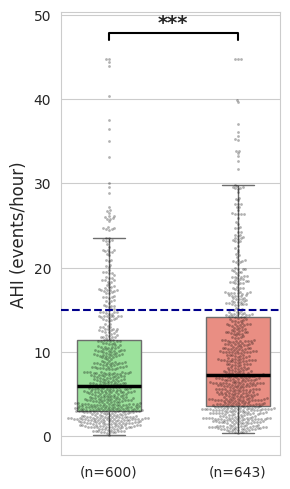

Top 25% - Mean AHI (SM): 9.80, Median: 7.19, N: 643
          Above 15: 142 (22.1%)
Bottom 25% - Mean AHI (SM): 8.38, Median: 5.92, N: 600
             Above 15: 98 (16.3%)

Mann-Whitney U test:
  U-statistic: 213956.00
  p-value: 0.0009


In [205]:
# create AHI comparison plot for males
ahi_comparison_results_male = create_biomarker_comparison_plot(
    predictions_table=predictions_table_merged,
    agg_top_indices=agg_top,
    agg_bottom_indices=agg_bottom,
    column_name='AHI (SM)',
    threshold=15,
    threshold_label='Sleep Apnea Threshold (AHI=15)',
    keep_last_per_subject=True,
    output_path=Figs_path,
    showflier=False,
    title=f'AHI Comparison: Top vs Bottom 25% Predicted Age - {gender}',
    ylabel='AHI (events/hour)',
    output_filename=f'AHI_{gender}',
    figsize=(3, 5),
    show_legend=False
)

/tmp/ipykernel_71040/2883139015.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_71040/2883139015.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'(n={bottom_total})', f'(n={top_total})'])


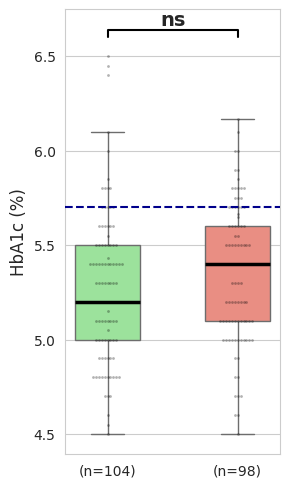

Top 25% - Mean HbA1C (BT): 5.35, Median: 5.40, N: 98
          Above 5.7: 15 (15.3%)
Bottom 25% - Mean HbA1C (BT): 5.27, Median: 5.20, N: 104
             Above 5.7: 10 (9.6%)

Mann-Whitney U test:
  U-statistic: 5830.50
  p-value: 0.0762


In [206]:
# create HbA1c comparison plot
hba1c_comparison_results = create_biomarker_comparison_plot(
    predictions_table=predictions_table_merged,
    agg_top_indices=agg_top,
    agg_bottom_indices=agg_bottom,
    column_name='HbA1C (BT)',
    threshold=5.7,
    threshold_label='Prediabetes Threshold (HbA1c=5.7)',
    keep_last_per_subject=True,
    output_path=Figs_path,
    showflier=False,
    title='HbA1c Comparison: Top vs Bottom 25% Predicted Age',
    ylabel='HbA1c (%)',
    output_filename='hba1c_{gender}',
    figsize=(3,5)
)

/tmp/ipykernel_71040/2883139015.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_71040/2883139015.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'(n={bottom_total})', f'(n={top_total})'])
/tmp/ipykernel_71040/2883139015.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'(n={bottom_total})', f'(n={top_total})'])


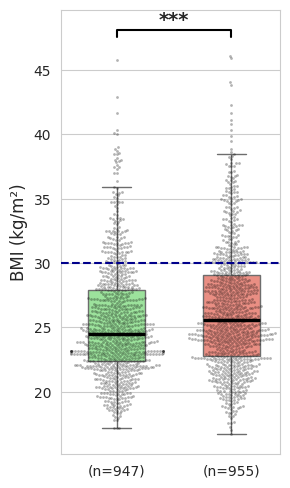

Top 25% - Mean BMI: 26.29, Median: 25.55, N: 955
          Above 30: 193 (20.2%)
Bottom 25% - Mean BMI: 25.33, Median: 24.50, N: 947
             Above 30: 131 (13.8%)

Mann-Whitney U test:
  U-statistic: 507004.50
  p-value: 0.0000


In [207]:
# plot for BMI as well with obesity threshold
bmi_comparison_results = create_biomarker_comparison_plot(
    predictions_table=predictions_table_merged,
    agg_top_indices=agg_top,
    agg_bottom_indices=agg_bottom,
    column_name='BMI',
    threshold=30,
    threshold_label='Obesity Threshold (BMI=30)',
    keep_last_per_subject=True,
    output_path=Figs_path,
    showflier=False,
    title='BMI Comparison: Top vs Bottom 25% Predicted Age',
    ylabel='BMI (kg/m²)',
    output_filename=f'bmi_{gender}',
    figsize=(3,5)
)

/tmp/ipykernel_71040/2883139015.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_71040/2883139015.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'(n={bottom_total})', f'(n={top_total})'])
/tmp/ipykernel_71040/2883139015.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'(n={bottom_total})', f'(n={top_total})'])
/net/mraid20/export/jasmine/david/anaconda3/envs/freshEnv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 8.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/net/mraid20/export/jasmine

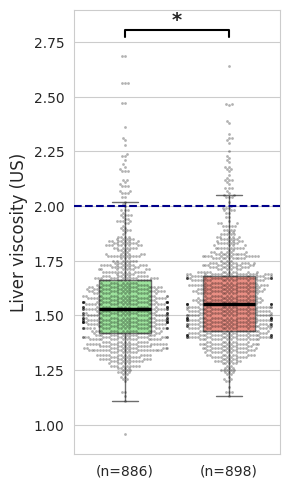

Top 25% - Mean Liver viscosity (US): 1.58, Median: 1.55, N: 898
          Above 2.0: 39 (4.3%)
Bottom 25% - Mean Liver viscosity (US): 1.56, Median: 1.53, N: 886
             Above 2.0: 37 (4.2%)

Mann-Whitney U test:
  U-statistic: 423399.00
  p-value: 0.0187


In [208]:
# plot for Liver Viscosity with clinical threshold
liver_viscosity_comparison_results = create_biomarker_comparison_plot(
    predictions_table=predictions_table_merged,
    agg_top_indices=agg_top,
    agg_bottom_indices=agg_bottom,
    column_name='Liver viscosity (US)',
    threshold=2.0,
    threshold_label='Clinical Threshold (Liver Viscosity=5.0)',
    keep_last_per_subject=True,
    output_path=Figs_path,
    showflier=False,
    title=f'Liver Viscosity - {gender}',
    ylabel='Liver viscosity (US)',
    output_filename=f'liver_viscosity_{gender}',
    figsize=(3,5)
)

/tmp/ipykernel_71040/2883139015.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_71040/2883139015.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'(n={bottom_total})', f'(n={top_total})'])
/tmp/ipykernel_71040/2883139015.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'(n={bottom_total})', f'(n={top_total})'])


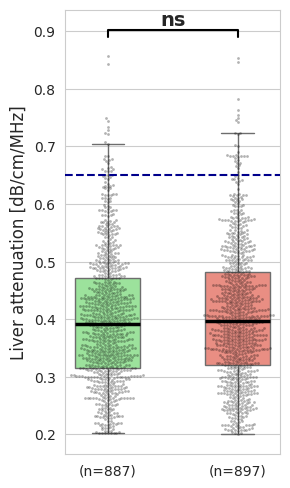

Top 25% - Mean Liver attenuation (US): 0.41, Median: 0.40, N: 897
          Above 0.65: 31 (3.5%)
Bottom 25% - Mean Liver attenuation (US): 0.40, Median: 0.39, N: 887
             Above 0.65: 27 (3.0%)

Mann-Whitney U test:
  U-statistic: 411812.00
  p-value: 0.1984


In [209]:
# plot for liver attenuation with clinical threshold
liver_attenuation_comparison_results = create_biomarker_comparison_plot(
    predictions_table=predictions_table_merged,
    agg_top_indices=agg_top,
    agg_bottom_indices=agg_bottom,
    column_name='Liver attenuation (US)',
    threshold=0.65,
    threshold_label='Clinical Threshold (Liver Attenuation=48)',
    keep_last_per_subject=True,
    output_path=Figs_path,
    showflier=False,
    title='Liver Attenuation Comparison: Top vs Bottom 25% Predicted Age',
    ylabel='Liver attenuation [dB/cm/MHz]',
    output_filename=f'liver_attenuation_{gender}',
    figsize=(3,5)
)

/tmp/ipykernel_71040/2883139015.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_71040/2883139015.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'(n={bottom_total})', f'(n={top_total})'])
/tmp/ipykernel_71040/2883139015.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'(n={bottom_total})', f'(n={top_total})'])


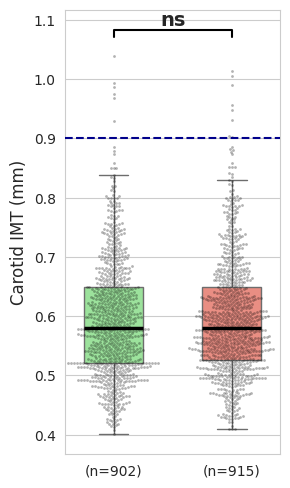

Top 25% - Mean Carotid - intima media thickness (US): 0.60, Median: 0.58, N: 915
          Above 0.9: 8 (0.9%)
Bottom 25% - Mean Carotid - intima media thickness (US): 0.59, Median: 0.58, N: 902
             Above 0.9: 6 (0.7%)

Mann-Whitney U test:
  U-statistic: 417577.00
  p-value: 0.6605


In [210]:
carotid_comparison_results = create_biomarker_comparison_plot(
    predictions_table=predictions_table_merged,
    agg_top_indices=agg_top,
    agg_bottom_indices=agg_bottom,
    column_name='Carotid - intima media thickness (US)',
    threshold=0.9,
    threshold_label='Clinical Threshold (Carotid IMT=0.9)',
    keep_last_per_subject=False,
    output_path=Figs_path,
    showflier=False,
    title=f'Carotid Intima-Media Thickness Comparison: Top vs Bottom 25% Predicted Age - {gender}',
    ylabel='Carotid IMT (mm)',
    output_filename=f'carotid_imt_{gender}',
    figsize=(3,5)
)

/tmp/ipykernel_71040/2883139015.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_71040/2883139015.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'(n={bottom_total})', f'(n={top_total})'])
/tmp/ipykernel_71040/2883139015.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'(n={bottom_total})', f'(n={top_total})'])
/net/mraid20/export/jasmine/david/anaconda3/envs/freshEnv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 7.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/net/mraid20/export/jasmine

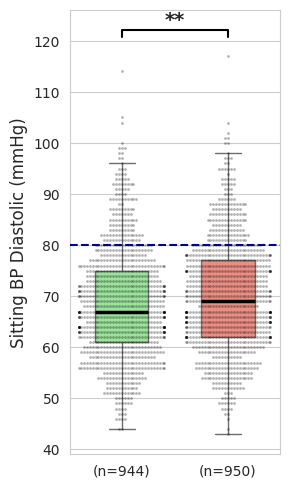

Top 25% - Mean Sitting BP diastolic: 69.92, Median: 69.00, N: 950
          Above 80: 143 (15.1%)
Bottom 25% - Mean Sitting BP diastolic: 68.54, Median: 67.00, N: 944
             Above 80: 125 (13.2%)

Mann-Whitney U test:
  U-statistic: 484121.00
  p-value: 0.0027


In [211]:
sitting_bp_diastolic_results = create_biomarker_comparison_plot(
    predictions_table=predictions_table_merged,
    agg_top_indices=agg_top,
    agg_bottom_indices=agg_bottom,
    column_name='Sitting BP diastolic',
    threshold=80,
    threshold_label='Hypertension Threshold (Sitting BP Diastolic=80)',
    keep_last_per_subject=True,
    output_path=Figs_path,
    showflier=False,
    title=f'Sitting BP Diastolic Comparison: Top vs Bottom 25% Predicted Age - {gender}',
    ylabel='Sitting BP Diastolic (mmHg)',
    output_filename=f'sitting_bp_diastolic_{gender}',
    figsize=(3,5),
    show_legend=False
)

/tmp/ipykernel_2378611/2187263088.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2378611/2187263088.py:157: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'(n={bottom_total})', f'(n={top_total})'])


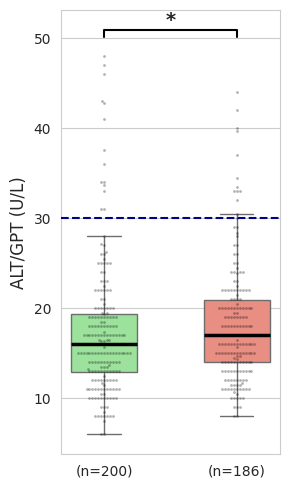

Top 25% - Mean ALT\GPT (BT): 18.06, Median: 17.00, N: 186
          Above 30: 12 (6.5%)
Bottom 25% - Mean ALT\GPT (BT): 17.30, Median: 16.00, N: 200
             Above 30: 14 (7.0%)

Mann-Whitney U test:
  U-statistic: 20525.00
  p-value: 0.0785


In [20]:
alt_gpt_comparison_results = create_biomarker_comparison_plot(
    predictions_table=predictions_table_merged,
    agg_top_indices=agg_top,
    agg_bottom_indices=agg_bottom,
    column_name='ALT\GPT (BT)',
    threshold=30,
    threshold_label='Clinical Threshold (ALT/GPT=30)',
    keep_last_per_subject=True,
    output_path=Figs_path,
    showflier=False,
    title=f'ALT/GPT Comparison: Top vs Bottom 25% Predicted Age - {gender}',
    ylabel='ALT/GPT (U/L)',
    output_filename=f'alt_gpt_{gender}',
    figsize=(3, 5),
    show_legend=False
)

## Correlation of predictions plots